# 05 — Business Value Analysis

**Input:** `data/processed/y_proba.parquet`, `y_test.parquet`  
**Output:** Threshold optimisation chart, cost breakdown table

Standard ML metrics (AUC, F1) treat all errors equally. In a banking
retention context they are not equal:

| Error type | Business cost |
|---|---|
| False negative (missed churner) | ~€800 lost annual revenue |
| False positive (false alarm) | ~€30 retention campaign cost |

This notebook reframes threshold selection as a **revenue optimisation
problem** and shows that the standard 0.5 threshold is rarely the business optimum.

> Cost assumptions are based on Bain & Company European retail banking  
> benchmarks (2023).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False})

y_test  = pd.read_parquet('data/processed/y_test.parquet').squeeze()
y_proba = pd.read_parquet('data/processed/y_proba.parquet')['y_proba'].values

print(f'Test set: {len(y_test):,} customers | churn rate: {y_test.mean():.1%}')

Test set: 2,000 customers | churn rate: 54.4%


## 1. Cost constants

In [2]:
# Adjust these if you have access to internal benchmarks
COST_FN      = 800   # €: annual revenue lost per missed churner
COST_FP      = 30    # €: outbound retention campaign (call + offer)
REVENUE_TP   = 400   # €: partial revenue saved per successful retention
              #         assumes ~50% success rate on contacted churners

print(f'Cost of missing a churner (FN) : €{COST_FN}')
print(f'Cost of a false alert     (FP) : €{COST_FP}')
print(f'Revenue saved per TP           : €{REVENUE_TP}')

Cost of missing a churner (FN) : €800
Cost of a false alert     (FP) : €30
Revenue saved per TP           : €400


## 2. Business cost at default threshold (0.5)

In [3]:
def cost_at_threshold(y_true, y_proba, threshold):
    """Return a cost breakdown dict for a given decision threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    cost_fn    = fn * COST_FN
    cost_fp    = fp * COST_FP
    revenue_tp = tp * REVENUE_TP
    net        = revenue_tp - cost_fn - cost_fp

    return {
        'threshold': threshold,
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'cost_missed_churners': cost_fn,
        'cost_false_alerts':    cost_fp,
        'revenue_saved':        revenue_tp,
        'net_value':            net,
    }

default = cost_at_threshold(y_test, y_proba, threshold=0.5)

print(f'At threshold 0.50:')
print(f'  Churners flagged (TP) : {default["TP"]:>5}')
print(f'  Churners missed  (FN) : {default["FN"]:>5}  →  -€{default["cost_missed_churners"]:>8,.0f}')
print(f'  False alerts     (FP) : {default["FP"]:>5}  →  -€{default["cost_false_alerts"]:>8,.0f}')
print(f'  Revenue saved         :          +€{default["revenue_saved"]:>8,.0f}')
print(f'  Net value             :           €{default["net_value"]:>8,.0f}')

At threshold 0.50:
  Churners flagged (TP) :  1055
  Churners missed  (FN) :    32  →  -€  25,600
  False alerts     (FP) :   436  →  -€  13,080
  Revenue saved         :          +€ 422,000
  Net value             :           € 383,320


## 3. Threshold sweep — find the business optimum

The curve below is the key chart for the LinkedIn post: it shows that the
default 0.5 threshold leaves significant revenue on the table.

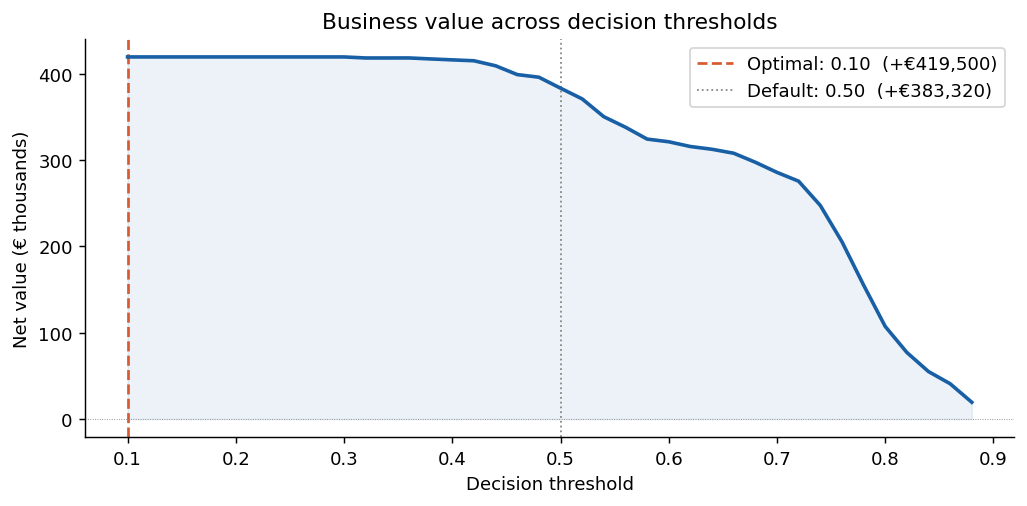

Optimal threshold : 0.10
Revenue uplift vs default threshold : +€36,180


In [4]:
thresholds = np.arange(0.10, 0.90, 0.02)
net_values = [cost_at_threshold(y_test, y_proba, t)['net_value'] for t in thresholds]

best_idx = int(np.argmax(net_values))
best_t   = thresholds[best_idx]
best_val = net_values[best_idx]

# Default threshold value for comparison
default_idx = int(np.argmin(np.abs(thresholds - 0.5)))
default_val = net_values[default_idx]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(thresholds, [v / 1_000 for v in net_values],
        color='#185FA5', linewidth=2, zorder=3)
ax.fill_between(thresholds, [v / 1_000 for v in net_values], 0,
                alpha=0.08, color='#185FA5')
ax.axvline(best_t, color='#D85A30', linestyle='--', linewidth=1.5,
           label=f'Optimal: {best_t:.2f}  (+€{best_val:,.0f})')
ax.axvline(0.5, color='#888780', linestyle=':', linewidth=1,
           label=f'Default: 0.50  (+€{default_val:,.0f})')
ax.axhline(0, color='#888780', linewidth=0.5, linestyle=':')

ax.set_xlabel('Decision threshold')
ax.set_ylabel('Net value (€ thousands)')
ax.set_title('Business value across decision thresholds')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('reports/figures/05_threshold_optimisation.png', bbox_inches='tight')
plt.show()

uplift = best_val - default_val
print(f'Optimal threshold : {best_t:.2f}')
print(f'Revenue uplift vs default threshold : +€{uplift:,.0f}')

## 4. Final cost breakdown at optimal threshold

In [5]:
optimal = cost_at_threshold(y_test, y_proba, threshold=best_t)

summary = pd.DataFrame([
    {'Threshold': 0.50,   **cost_at_threshold(y_test, y_proba, 0.50)},
    {'Threshold': best_t, **optimal},
]).set_index('Threshold')[['TP', 'FN', 'FP', 'net_value']]

summary.columns = ['Churners flagged (TP)', 'Churners missed (FN)',
                   'False alerts (FP)', 'Net value (€)']
summary['Net value (€)'] = summary['Net value (€)'].map('€{:,.0f}'.format)
summary

,Churners flagged (TP),Churners missed (FN),False alerts (FP),Net value (€)
Threshold,,,,
0.5,1055,32,436,"€383,320"
0.1,1087,0,510,"€419,500"


## 5. Classification report at optimal threshold

In [6]:
y_pred_optimal = (y_proba >= best_t).astype(int)
print(f'Classification report at threshold {best_t:.2f}:\n')
print(classification_report(y_test, y_pred_optimal,
                             target_names=['Retained', 'Churned']))

Classification report at threshold 0.10:

              precision    recall  f1-score   support

    Retained       1.00      0.44      0.61       913
     Churned       0.68      1.00      0.81      1087

    accuracy                           0.74      2000
   macro avg       0.84      0.72      0.71      2000
weighted avg       0.83      0.74      0.72      2000

